# Ocean Carbon Sampling
## A map-first visual story of fixed-sample-count observing strategies

<div style="padding:16px 18px;border-left:5px solid #0F766E;background:#F0FDFA;">
<b>Question</b><br>At a fixed annual sample count, does changing <i>where</i> we sample redistribute global monthly reconstruction risk?
</div>

**Demo status:** scientific content is source-grounded; layout remains open for portfolio refinement.

In [1]:
from pathlib import Path

import pandas as pd

from ocean_carbon_sampling.demo_visuals import (
    plot_budget_sweep,
    plot_error_atlas,
    plot_sampling_atlas,
    plot_spatial_holdout_gate,
)

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
RESULTS = ROOT / 'results' / 'public'
fields = pd.read_parquet(RESULTS / 'osse_visual_demo_fields.parquet')
sampling = pd.read_parquet(RESULTS / 'osse_visual_demo_sampling.parquet')
metadata = pd.read_csv(RESULTS / 'osse_visual_demo_metadata.csv')
effects = pd.read_csv(RESULTS / 'osse_cross_year_paired_summary.csv')
regrid = pd.read_csv(RESULTS / 'osse_regrid_audit_paired_summary.csv')
spatial_blocks = pd.read_csv(RESULTS / 'osse_spatial_block_confirmatory_blocks.csv')
spatial_summary = pd.read_csv(RESULTS / 'osse_spatial_block_confirmatory_paired_summary.csv')
month_balance = pd.read_csv(RESULTS / 'osse_month_balance_strategy_summary.csv')
claim_summary = pd.read_csv(RESULTS / 'osse_claim_distribution_summary.csv')
truth_scale = pd.read_csv(RESULTS / 'osse_truth_scale.csv')
print('Curated visual-demo data loaded.')

Curated visual-demo data loaded.


In [2]:
metadata.rename(columns={
    'complete_month_cells': 'complete month-grid cells',
    'evaluation_month_cells': 'hidden evaluation rows',
    'map_grid_cells': 'mapped spatial cells',
})

,year,seed,error_map_seeds,n_error_map_seeds,budget,complete month-grid cells,candidate_month_cells,hidden evaluation rows,mapped spatial cells,sampling_longitude_degrees,sampling_latitude_degrees,map_role
0,2005,0,0;1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;19,20,5000,487488,390000,97488,40624,10.0,5.0,error fields are paired-seed means; sampling g...


## 0 · What is being predicted—and why monthly?

This project evaluates **reconstruction under a fixed annual sample count**, not future-time forecasting. The truth field is monthly surface-ocean `spco2` from the CMIP6 IPSL-CM6A-LR historical Earth-system-model simulation (`r1i1p1f1`)—not a SOCAT-derived reconstruction. SST and salinity from the same simulation are predictors; SOCAT only defines the historical observing-pattern baseline.

Each record is a month–location observation, but all 12 months are fitted jointly in one model. Cyclic month features preserve the seasonal cycle and keep December adjacent to January.

The random hidden set is stratified by month so every season has the same evaluation fraction; otherwise seasonal test composition could be mistaken for a sampling-strategy effect. In the stricter spatial holdout, all 12 months from one location stay in the same fold, preventing the model from training on another month at the evaluation location. A chronological split would instead test forecasting under temporal distribution shift—a valid but different question.

In [3]:
month_balance_appendix = month_balance.query('budget == 5000').assign(
    strategy=lambda frame: frame['strategy'].replace({
        'random': 'Random',
        'spatial_coverage': 'Seasonally balanced spatial coverage',
        'historical_density': 'Historical spatiotemporal pattern',
    }),
    mean_abs_equal_deviation_pp=lambda frame: frame['mean_abs_equal_deviation_pp'].round(3),
    mean_max_abs_equal_deviation_pp=lambda frame: frame['mean_max_abs_equal_deviation_pp'].round(3),
)[['strategy', 'n_year_fold_seed_selections', 'minimum_months_covered',
   'mean_abs_equal_deviation_pp', 'mean_max_abs_equal_deviation_pp']]

A selection-only audit confirms that all 1,800 selections cover all 12 months and that random and coverage have closely matched month shares. The detailed audit is moved to the appendix. Historical density remains a realistic **spatiotemporal** baseline, not a pure spatial control.

## 1 · Same sample count, different observing geometry

Each strategy selects exactly 5,000 month-grid observations from the same candidate pool. Random and seasonally balanced spatial coverage have closely matched monthly allocation, so this map isolates their main difference: where observations are placed. Colour encodes the number selected within each 5° × 10° spatial block; no observations are discarded for plotting.

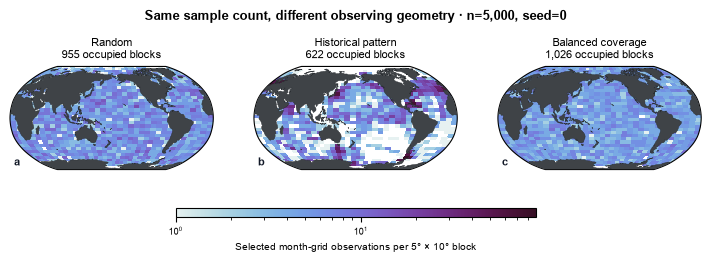

In [4]:
sampling_figure = plot_sampling_atlas(sampling, budget=5000, seed=0)

<div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:10px;margin:10px 0 22px 0;">
<div style="padding:10px;background:#F9FAFB;border-radius:6px;"><b>Random</b><br>Broad but uneven by chance.</div>
<div style="padding:10px;background:#FFF7ED;border-radius:6px;"><b>Historical pattern</b><br>Reproduces seasonal and spatial observation density.</div>
<div style="padding:10px;background:#F0FDFA;border-radius:6px;"><b>Balanced spatial coverage</b><br>Cycles across month × under-filled spatial blocks.</div>
</div>

## 2 · Where does coverage change error?

The maps below use every row of the locked 2005 hidden evaluation set and average absolute error over all 20 paired seeds. The hero panel shows the change in mean absolute error: blue cells favour coverage; red cells favour random. Stippling marks cells where at least 16/20 seed-level spatial ΔMAE values share the same sign. Values beyond the 98th percentile are colour-clipped only to protect contrast; they remain in all calculations.

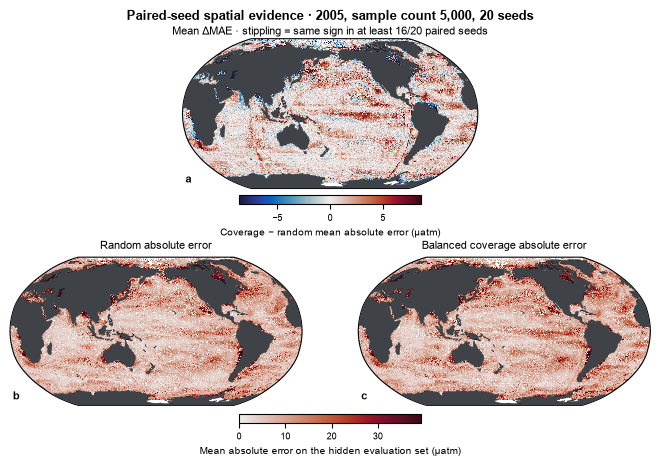

In [5]:
error_figure = plot_error_atlas(fields)

**Reading boundary.** This map uses 2005 and sample count 5,000 to localise the 20-seed paired effect. It is quantitative spatial evidence, but the grid cells are not independent replicates; inference remains at the paired-seed and year–fold levels.

## 3 · Absolute scale and sample-count boundary

Differences are interpretable only beside their absolute baselines and the intrinsic scale of the truth field. The first table gives a no-extra-assumptions reference from the locked `spco2` truth fields. The second reports random and comparator absolute errors, their differences, and percentage changes at sample count 5,000. Signed-bias percentages are undefined because the random denominators are near zero.

The figure then uses every locked sample count (500, 1,000, 2,500 and 5,000), all 20 paired sampling seeds and each of three prespecified years. Points are paired-seed mean differences and intervals are 10,000-resample seed-bootstrap 95% intervals. The metrics and years are correlated views of the same experiment, not independent tests.

In [6]:
truth_scale.query("scope == 'pooled_prespecified_years'").assign(
    month_cell_standard_deviation_uatm=lambda frame: frame['month_cell_standard_deviation_uatm'].round(1),
    annual_mean_spatial_standard_deviation_uatm=lambda frame: frame['annual_mean_spatial_standard_deviation_uatm'].round(1),
    median_local_seasonal_amplitude_uatm=lambda frame: frame['median_local_seasonal_amplitude_uatm'].round(1),
)[[
    'scope', 'n_finite_month_cells', 'month_cell_standard_deviation_uatm',
    'annual_mean_spatial_standard_deviation_uatm',
    'median_local_seasonal_amplitude_uatm',
]]

,scope,n_finite_month_cells,month_cell_standard_deviation_uatm,annual_mean_spatial_standard_deviation_uatm,median_local_seasonal_amplitude_uatm
3,pooled_prespecified_years,1462464,44.9,31.0,58.8


In [7]:
absolute_scale = claim_summary.query('budget == 5000').assign(
    validation=lambda frame: frame['validation_scheme'].replace({
        'month_stratified_hidden_cells': 'Hidden cells',
        'whole_spatial_blocks': 'Whole blocks',
    }),
    comparator=lambda frame: frame['comparison'].replace({
        'spatial_coverage_minus_random': 'Coverage',
        'historical_density_minus_random': 'Historical pattern',
    }),
    random=lambda frame: frame['mean_random_baseline'].round(3),
    comparator_value=lambda frame: frame['mean_comparator_value'].round(3),
    difference=lambda frame: frame['mean_difference'].round(3),
    relative_change_percent=lambda frame: frame['mean_relative_error_change_percent'].round(2),
)[[
    'validation', 'comparator', 'metric', 'random', 'comparator_value',
    'difference', 'relative_change_percent',
]]
absolute_scale.sort_values(['validation', 'comparator', 'metric'])

,validation,comparator,metric,random,comparator_value,difference,relative_change_percent
42,Hidden cells,Coverage,bias,0.065,0.071,0.006,NaN
43,Hidden cells,Coverage,mae,10.936,11.436,0.500,4.56
44,Hidden cells,Coverage,median_absolute_error,7.083,7.754,0.670,9.47
45,Hidden cells,Coverage,p95_absolute_error,30.696,31.785,1.090,3.55
46,Hidden cells,Coverage,p99_absolute_error,66.406,61.686,-4.720,-7.10
47,Hidden cells,Coverage,rmse,25.936,24.829,-1.107,-4.23
36,Hidden cells,Historical pattern,bias,0.065,-4.822,-4.887,NaN
37,Hidden cells,Historical pattern,mae,10.936,16.366,5.430,49.65
38,Hidden cells,Historical pattern,median_absolute_error,7.083,9.057,1.974,27.85
39,Hidden cells,Historical pattern,p95_absolute_error,30.696,56.371,25.676,83.72


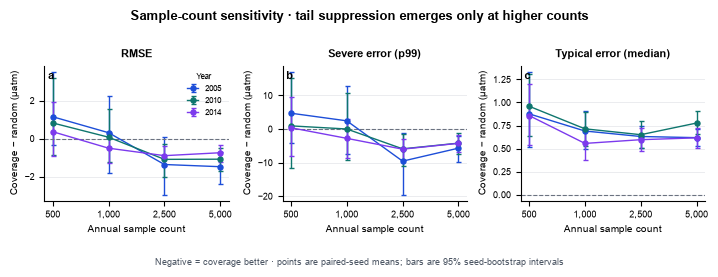

In [8]:
key_effects = effects.query(
    "evaluation_domain == 'all' and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
).copy()
budget_sweep_figure = plot_budget_sweep(key_effects)

In [9]:
key_effects.query('budget == 5000').assign(
    mean_difference=lambda frame: frame['mean_difference'].round(3),
    seed_bootstrap_low=lambda frame: frame['seed_bootstrap_low'].round(3),
    seed_bootstrap_high=lambda frame: frame['seed_bootstrap_high'].round(3),
)[[
    'year', 'metric', 'n_seeds', 'mean_difference',
    'seed_bootstrap_low', 'seed_bootstrap_high',
]].sort_values(['metric', 'year'])

,year,metric,n_seeds,mean_difference,seed_bootstrap_low,seed_bootstrap_high
36,2005,median_absolute_error,20,0.618,0.525,0.709
116,2010,median_absolute_error,20,0.777,0.655,0.904
196,2014,median_absolute_error,20,0.616,0.509,0.726
38,2005,p99_absolute_error,20,-5.701,-9.844,-1.952
118,2010,p99_absolute_error,20,-4.207,-7.562,-1.113
198,2014,p99_absolute_error,20,-4.253,-6.767,-1.877
39,2005,rmse,20,-1.484,-2.376,-0.701
119,2010,rmse,20,-1.088,-1.705,-0.507
199,2014,rmse,20,-0.749,-1.213,-0.315


**Sample-count boundary.** At 500 observations, coverage is worse than random in all three years not only through the median but also at p99 and RMSE: the extreme-tail suppression has not yet emerged. At 2,500 and 5,000, mean p99 falls in all three years, while median error remains higher at every tested count. Coverage therefore shifts error from the extreme tail into the more common sub-p95 range only after the sample count is sufficiently high; this is not a count-invariant advantage.

### Supporting audit · Spatial weighting

At sample count 5,000, replacing equal weighting within one-degree bins with native-cell-area weighting preserves the directions of the three displayed coverage-versus-random metrics. These correlated metrics are an audit of one result, not independent tests.

In [10]:
audit_filter = (
    "evaluation_domain == 'all' and budget == 5000 and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
)
equal_bin = key_effects.query('budget == 5000').assign(method='equal-bin baseline')
area_weighted = regrid.query(audit_filter).assign(method='native-cell-area audit')
robustness = pd.concat([equal_bin, area_weighted], ignore_index=True)
robustness.pivot_table(
    index=['year', 'metric'], columns='method', values='mean_difference'
).round(3)

method                      equal-bin baseline  native-cell-area audit
year metric                                                           
2005 median_absolute_error               0.618                   0.637
     p99_absolute_error                 -5.701                  -5.693
     rmse                               -1.484                  -1.464
2010 median_absolute_error               0.777                   0.747
     p99_absolute_error                 -4.207                  -5.025
     rmse                               -1.088                  -1.153
2014 median_absolute_error               0.616                   0.594
     p99_absolute_error                 -4.253                  -4.264
     rmse                               -0.749                  -0.692

## 4 · Stricter validation: whole regions unseen

### What is a Global spatial-block holdout OSSE?

An **OSSE** (Observing System Simulation Experiment) treats a complete climate-model field as known truth, simulates where observations would be collected, reconstructs the unsampled ocean, and scores that reconstruction against the truth. A **spatial-block holdout** makes the test harder: instead of hiding scattered cells, it withholds whole geographic blocks. The model therefore cannot learn from another month at the same location or from a randomly hidden neighbour inside the held-out block.

Here, all 12 months of each 20° × 10° block stay together. Five checkerboard folds exhaust the occupied ocean blocks: one fold is evaluated while the other four provide candidates, repeated until every block has been held out once. The confirmatory comparison repeats this design in the prespecified years 2005, 2010 and 2014, using the same model, equal sample counts, 20 paired sampling seeds per year–fold, and seed-bootstrap intervals. There is no extra buffer around held-out blocks, so this is a coarse unseen-region gate rather than a long-range extrapolation test.

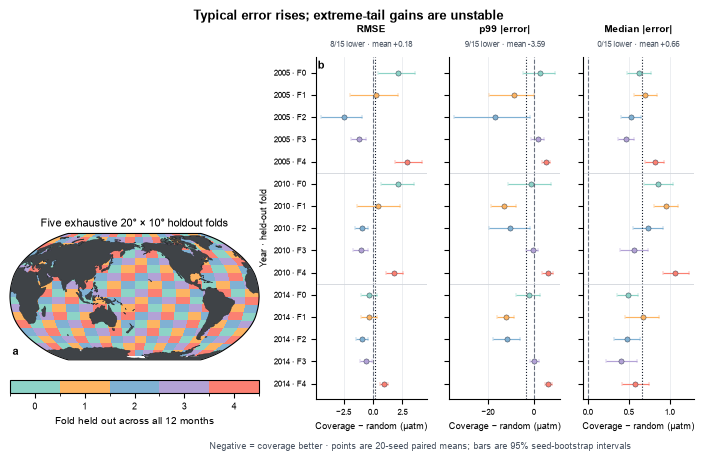

In [11]:
spatial_gate_figure = plot_spatial_holdout_gate(spatial_blocks, spatial_summary)

**One mechanism under both validation schemes.** At sample count 5,000, coverage raises median, MAE and p95 error in essentially every whole-block unit: MAE and median are higher in 15/15, and p95 is higher in 14/15. Its mean p99 difference is **−3.590 µatm**, but only 9/15 units favour coverage; this tail benefit is not directionally stable. RMSE is lower in 8/15 and higher in 7/15, with a descriptive mean of **+0.179 µatm**.

The same distributional shift already appears in random hidden cells: coverage is worse through p95 but better at p99. Because RMSE squares errors, its hidden-cell improvement is driven by those rare large errors and is not evidence of broad improvement across the error distribution. Whole-block validation does not reveal a separate regime; it shows that the extreme-tail benefit becomes unstable when complete regions are unseen. Negative differences favour coverage.

The 15 year–fold units are a descriptive consistency check, not independent replicates; the three years share persistent spatial structure because they come from the same model run.

## 5 · Absolute scale and year–fold distribution

Differences alone are not enough to judge practical size. The first table reports random and coverage absolute values at sample count 5,000, plus percentage change for non-signed metrics. The second reports the full distribution across validation units rather than only the mean.

In [12]:
whole_block_distribution = claim_summary.query(
    "validation_scheme == 'whole_spatial_blocks' and budget == 5000"
).assign(
    comparator=lambda frame: frame['comparison'].replace({
        'spatial_coverage_minus_random': 'Coverage',
        'historical_density_minus_random': 'Historical pattern',
    }),
    random=lambda frame: frame['mean_random_baseline'].round(3),
    comparator_value=lambda frame: frame['mean_comparator_value'].round(3),
    mean_difference=lambda frame: frame['mean_difference'].round(3),
    median=lambda frame: frame['median_difference'].round(3),
    q25=lambda frame: frame['q25_difference'].round(3),
    q75=lambda frame: frame['q75_difference'].round(3),
    minimum=lambda frame: frame['minimum_difference'].round(3),
    maximum=lambda frame: frame['maximum_difference'].round(3),
)[[
    'comparator', 'metric', 'n_units', 'random', 'comparator_value',
    'mean_difference', 'median', 'q25', 'q75', 'minimum', 'maximum',
    'units_below_zero', 'units_above_zero',
]]
whole_block_distribution.sort_values(['comparator', 'metric'])

,comparator,metric,n_units,random,comparator_value,mean_difference,median,q25,q75,minimum,maximum,units_below_zero,units_above_zero
66,Coverage,bias,15,0.104,0.256,0.152,0.320,-0.429,0.557,-0.657,1.017,6,9
67,Coverage,mae,15,12.828,13.460,0.632,0.550,0.383,0.815,0.160,1.379,0,15
68,Coverage,median_absolute_error,15,8.295,8.958,0.663,0.626,0.509,0.775,0.409,1.069,0,15
69,Coverage,p95_absolute_error,15,36.588,37.846,1.257,1.273,0.601,1.635,-0.023,3.055,1,14
70,Coverage,p99_absolute_error,15,80.367,76.777,-3.590,-1.002,-11.106,2.207,-16.788,6.294,9,6
71,Coverage,rmse,15,27.549,27.728,0.179,-0.321,-0.940,1.368,-2.496,2.922,8,7
60,Historical pattern,bias,15,0.104,-4.851,-4.954,-5.257,-5.613,-4.316,-6.188,-3.358,15,0
61,Historical pattern,mae,15,12.828,17.809,4.981,4.835,4.550,5.400,3.910,6.131,0,15
62,Historical pattern,median_absolute_error,15,8.295,10.382,2.087,2.138,1.946,2.220,1.468,2.554,0,15
63,Historical pattern,p95_absolute_error,15,36.588,59.571,22.982,23.125,19.051,25.983,15.565,31.460,0,15


The historical-pattern result is both large and directionally consistent. For whole-block RMSE, random is **27.549 µatm** and historical-pattern sampling is **36.486 µatm**: a **+8.936 µatm** deterioration, with historical worse in **15/15** year–fold units. This is the strongest result under the present pointwise reconstruction objective, although the historical baseline combines spatial clustering with its observed monthly allocation and is not a pure spatial control.

For coverage, the whole-block p99 mean is −3.590 µatm, but its median is only −1.002 µatm, its IQR spans −11.106 to +2.207 µatm, and its range is −16.788 to +6.294 µatm. A subset of large improvements therefore pulls the mean negative. Global mean signed errors remain tiny beside RMSE: +0.065 versus +0.071 µatm in hidden cells and +0.104 versus +0.256 µatm in whole blocks for random versus coverage. Thus the comparison is primarily a redistribution of error magnitude rather than a global signed offset; near-zero global bias does not rule out cancelling regional biases.

A pointwise µatm error is not converted directly to PgC yr⁻¹: air–sea flux also requires gas-transfer velocity, solubility, atmospheric pCO₂ and cell area. The truth-scale table instead provides a direct contextual reference without adding a flux model. Integrated flux remains a separate, not-yet-supported decision metric.

---
## Result

<div style="padding:18px;background:#111827;color:#F9FAFB;border-radius:8px;font-size:16px;line-height:1.45;">
At sufficiently high sample counts, balanced coverage moves error out of the extreme tail but raises error throughout the more common sub-p95 range. The tail benefit is not directionally stable when complete ocean regions are unseen.
</div>

**Strong result:** reproducing the complete historical spatiotemporal observing pattern is much worse than random for pointwise reconstruction under this objective: whole-block RMSE increases by 8.936 µatm and historical is worse in 15/15 year–fold units. Its spatial and monthly contributions are not separated.  
**Bounded result:** coverage redistributes error rather than improving the whole distribution. Its hidden-cell RMSE decrease is tail-sensitive evidence, not a second independent sign of overall accuracy; under whole-block validation the p99 mean still favours coverage, but only 9/15 units do.  
**Not yet supported:** universal superiority, buffered extrapolation, cost-aware design, integrated air–sea carbon-flux accuracy, cross-model robustness, or direct real-ocean performance.

## 5 · Whole-block distributions and signed bias

The table exposes all 15 year–fold units for both coverage and the historical observing pattern. It reports absolute random and comparator means alongside the distribution of paired differences, so large means cannot hide directional inconsistency.

In [13]:
month_balance_appendix

,strategy,n_year_fold_seed_selections,minimum_months_covered,mean_abs_equal_deviation_pp,mean_max_abs_equal_deviation_pp
3,Historical spatiotemporal pattern,300,12,0.875,2.506
4,Random,300,12,0.292,0.754
5,Seasonally balanced spatial coverage,300,12,0.222,0.532
